In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load processed NAV history
nav = pd.read_csv("../DATA/PROCESSED/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
selected_funds = [
    "SBI Bluechip Fund - Regular Plan - Growth",
    "SBI Small Cap Fund - Regular Plan - Growth",
    "SBI Magnum Gilt Fund - Regular Plan - Growth",
    "HDFC Top 100 Fund - Regular Plan - Growth",
    "HDFC Mid-Cap Opportunities Fund - Regular - Growth"
]

print("Selected funds:")
for fund in selected_funds:
    print("-", fund)

Selected funds:
- SBI Bluechip Fund - Regular Plan - Growth
- SBI Small Cap Fund - Regular Plan - Growth
- SBI Magnum Gilt Fund - Regular Plan - Growth
- HDFC Top 100 Fund - Regular Plan - Growth
- HDFC Mid-Cap Opportunities Fund - Regular - Growth


In [7]:
fund_master = pd.read_csv("../DATA/PROCESSED/01_fund_master.csv")

selected_master = fund_master[
    fund_master["scheme_name"].isin(selected_funds)][["amfi_code", "scheme_name"]]

print(selected_master)

   amfi_code                                        scheme_name
0     119551          SBI Bluechip Fund - Regular Plan - Growth
2     119598         SBI Small Cap Fund - Regular Plan - Growth
4     119120       SBI Magnum Gilt Fund - Regular Plan - Growth
5     100016          HDFC Top 100 Fund - Regular Plan - Growth
7     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [8]:
# Keep only the selected AMFI codes
selected_codes = selected_master["amfi_code"].tolist()

selected_nav = nav[nav["amfi_code"].isin(selected_codes)].copy()

# Calculate daily returns
selected_nav["daily_return"] = (selected_nav.groupby("amfi_code")["nav"].pct_change())

# Convert to return matrix
return_matrix = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

# Remove dates where any selected fund has no return
return_matrix = return_matrix.dropna()

print("Return matrix shape:", return_matrix.shape)
print(return_matrix.head())

Return matrix shape: (1149, 5)
amfi_code     100016    100033    119120    119551    119598
date                                                        
2022-01-04 -0.010306 -0.013328  0.002651 -0.000702 -0.014735
2022-01-05  0.012865 -0.004386  0.004416  0.006247 -0.005161
2022-01-06 -0.011377 -0.005167  0.003598  0.014045  0.004824
2022-01-07 -0.001210 -0.005748 -0.002465 -0.001547  0.032830
2022-01-10 -0.008639  0.006277 -0.000353 -0.001548  0.051113


In [9]:
# Annualized expected returns
expected_returns = return_matrix.mean() * 252

# Annualized covariance matrix
cov_matrix = return_matrix.cov() * 252

print("Annualized Expected Returns:")
print((expected_returns * 100).round(2))

print("\nAnnualized Covariance Matrix:")
print(cov_matrix.round(4))

Annualized Expected Returns:
amfi_code
100016     3.57
100033    27.21
119120     5.60
119551    23.10
119598    30.27
dtype: float64

Annualized Covariance Matrix:
amfi_code  100016  100033  119120  119551  119598
amfi_code                                        
100016     0.0212 -0.0000 -0.0001  0.0008 -0.0011
100033    -0.0000  0.0359 -0.0001 -0.0004  0.0003
119120    -0.0001 -0.0001  0.0016  0.0001  0.0002
119551     0.0008 -0.0004  0.0001  0.0189  0.0008
119598    -0.0011  0.0003  0.0002  0.0008  0.0632


In [10]:
# Generate random portfolios

num_portfolios = 10000
num_funds = len(selected_codes)

portfolio_returns = []
portfolio_volatility = []
portfolio_sharpe = []
portfolio_weights = []

np.random.seed(42)

for _ in range(num_portfolios):

    # Random portfolio weights
    weights = np.random.random(num_funds)

    # Make weights sum to 1
    weights = weights / weights.sum()

    # Portfolio return
    port_return = np.dot(weights, expected_returns)

    # Portfolio risk
    port_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    # Sharpe ratio
    sharpe = port_return / port_volatility

    portfolio_returns.append(port_return)
    portfolio_volatility.append(port_volatility)
    portfolio_sharpe.append(sharpe)
    portfolio_weights.append(weights)

portfolio_returns = np.array(portfolio_returns)
portfolio_volatility = np.array(portfolio_volatility)
portfolio_sharpe = np.array(portfolio_sharpe)
portfolio_weights = np.array(portfolio_weights)

print("Portfolios generated:", num_portfolios)

Portfolios generated: 10000


In [12]:
# Find maximum Sharpe portfolio again

max_sharpe_idx = np.argmax(portfolio_sharpe)

max_sharpe_return = portfolio_returns[max_sharpe_idx]
max_sharpe_risk = portfolio_volatility[max_sharpe_idx]
max_sharpe_ratio = portfolio_sharpe[max_sharpe_idx]

max_sharpe_weights = portfolio_weights[max_sharpe_idx]

print("Maximum Sharpe Portfolio")
print("Expected Return:", round(max_sharpe_return * 100, 2), "%")
print("Risk:", round(max_sharpe_risk * 100, 2), "%")
print("Sharpe Ratio:", round(max_sharpe_ratio, 2))

Maximum Sharpe Portfolio
Expected Return: 14.69 %
Risk: 5.22 %
Sharpe Ratio: 2.81


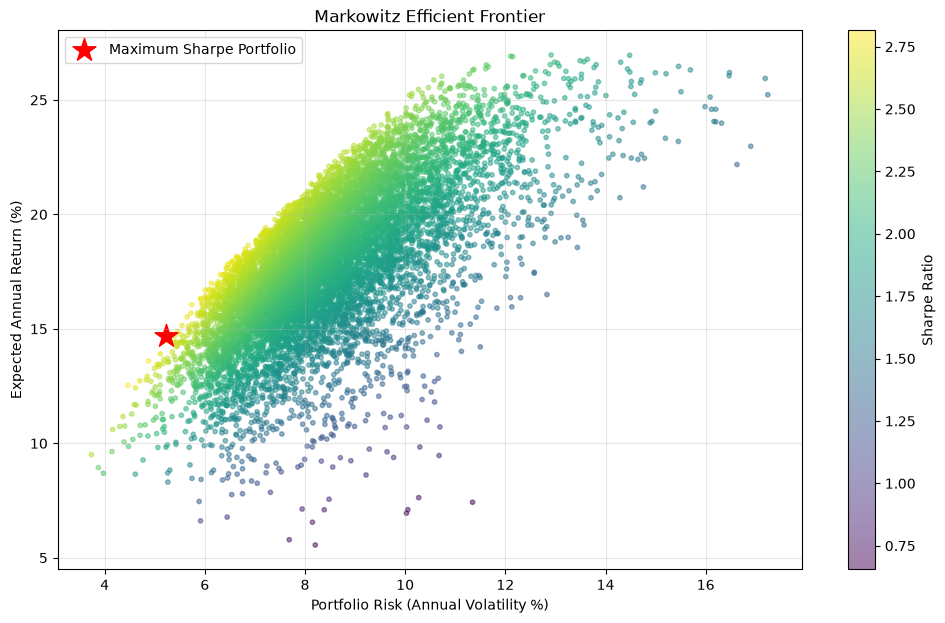

In [13]:
# Markowitz Efficient Frontier

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    portfolio_volatility * 100,
    portfolio_returns * 100,
    c=portfolio_sharpe,
    cmap="viridis",
    alpha=0.5,
    s=10
)

# Maximum Sharpe portfolio
plt.scatter(
    max_sharpe_risk * 100,
    max_sharpe_return * 100,
    marker="*",
    s=300,
    color="red",
    label="Maximum Sharpe Portfolio"
)

plt.xlabel("Portfolio Risk (Annual Volatility %)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Markowitz Efficient Frontier")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.3)

plt.show()